<a href="https://colab.research.google.com/github/zackdihel/DA-final-project/blob/main/5200_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 5200: Consulting Report — Final Project

**From Model to Recommendation**

This notebook scaffolds the full consulting report pipeline: executive summary, identification strategy, causal analysis, threats assessment, Streamlit export, presentation script, and AI methodology appendix.

---

## Part 0: Setup

In [48]:
!pip install linearmodels
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict

# Causal ML (uncomment the one you use)
# from econml.dml import LinearDML, CausalForestDML
# from doubleml import DoubleMLPLR, DoubleMLData

# Stats
from scipy import stats
import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
## Part 1: Executive Summary

Use SCR (Situation – Complication – Resolution) structure. Fill this in LAST, after your analysis is complete.

> **We estimate that [treatment] has an effect of [X] on [outcome] (95% CI: [a, b]).**
>
> **Situation:** ___
> **Complication:** ___
> **Resolution:** ___
>
> **We recommend [action] because [reason].**
>
> **Key assumption that could invalidate this:** ___

---
## Part 2: Data + Identification Strategy

### Research Design

- **Research question:** Does higher education attainment cause a lower probability of unemployment?
- **Identification strategy:** IV
- **Key assumption:** Exclusion Restriction: instrumental variable affects unemployment *only* through education. Instrumental variable will also be uncorrelated with unobserved predictors.
- **Treatment variable:** Education (college degree)
- **Outcome variable:** Employment status (unemployment)
- **Controls:** Age, race, sex, income, year, industry, ethnicity
- **Why prediction alone is insufficient:** Does not identify biases and causalities that can lead to the incorrect conclusions being drawn. IV will analyze what happens when education changes, and how that impacts unemployment.


In [49]:
# --- Data Loading ---
df = pd.read_csv('educ.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1777193, 23)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEFIP,STRATA,GQ,PERNUM,...,RACE,RACED,HISPAN,HISPAND,EDUC,EDUCD,EMPSTAT,EMPSTATD,IND,INCTOT
0,2000,200004,41,NaN,350.0,2000000000414,33,33,1,1,...,1,100,0,0,10,101,1,10,336,78200
1,2000,200004,41,NaN,350.0,2000000000414,33,33,1,2,...,1,100,0,0,10,101,1,10,786,4000
2,2000,200004,41,NaN,350.0,2000000000414,33,33,1,3,...,1,100,0,0,3,30,0,0,0,9999999
3,2000,200004,41,NaN,350.0,2000000000414,33,33,1,4,...,1,100,0,0,2,24,0,0,0,9999999
4,2000,200004,41,NaN,350.0,2000000000414,33,33,1,5,...,1,100,0,0,1,10,0,0,0,9999999


In [50]:
# --- EDA: Summary Statistics ---
df.describe()

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEFIP,STRATA,GQ,PERNUM,...,RACE,RACED,HISPAN,HISPAND,EDUC,EDUCD,EMPSTAT,EMPSTATD,IND,INCTOT
count,1.777193e+06,1.777193e+06,1.777193e+06,1.629637e+06,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06,...,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06,1.777193e+06
mean,2.013672e+03,2.013682e+05,6.035404e+05,8.315784e+11,1.086311e+02,2.013678e+12,2.640542e+01,1.611317e+05,1.146382e+00,2.014979e+00,...,1.698942e+00,1.738378e+02,2.119303e-01,2.277784e+01,6.564844e+00,6.798485e+01,1.443735e+00,1.446470e+01,4.032516e+03,1.624418e+06
std,6.501155e+00,6.500768e+02,1.320110e+05,9.943525e+11,9.856840e+01,6.501921e+09,3.044366e+00,1.540567e+05,6.163989e-01,1.228323e+00,...,1.844051e+00,1.888308e+02,8.176847e-01,8.934546e+01,3.380216e+00,3.387904e+01,1.082902e+00,1.082062e+01,3.704168e+03,3.634073e+06
min,2.000000e+03,2.000040e+05,4.100000e+01,3.000000e+00,1.000000e+00,2.000000e+12,2.500000e+01,2.500000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.999800e+04
25%,2.008000e+03,2.008010e+05,5.950070e+05,6.070040e+05,6.100000e+01,2.008008e+12,2.500000e+01,4.003300e+04,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+02,0.000000e+00,0.000000e+00,5.000000e+00,5.000000e+01,1.000000e+00,1.000000e+01,0.000000e+00,1.200000e+04
50%,2.014000e+03,2.014010e+05,6.127450e+05,1.218046e+06,8.400000e+01,2.014006e+12,2.500000e+01,8.052500e+04,1.000000e+00,2.000000e+00,...,1.000000e+00,1.000000e+02,0.000000e+00,0.000000e+00,6.000000e+00,6.500000e+01,1.000000e+00,1.000000e+01,4.470000e+03,4.000000e+04
75%,2.019000e+03,2.019010e+05,6.573660e+05,2.020000e+12,1.190000e+02,2.019006e+12,2.500000e+01,3.301250e+05,1.000000e+00,3.000000e+00,...,1.000000e+00,1.000000e+02,0.000000e+00,0.000000e+00,1.000000e+01,1.010000e+02,3.000000e+00,3.000000e+01,7.860000e+03,1.000000e+05
max,2.024000e+03,2.024010e+05,8.416860e+05,2.024010e+12,2.002000e+03,2.024008e+12,3.300000e+01,4.903250e+05,5.000000e+00,2.000000e+01,...,9.000000e+00,9.900000e+02,4.000000e+00,4.980000e+02,1.100000e+01,1.160000e+02,3.000000e+00,3.000000e+01,9.920000e+03,9.999999e+06


In [51]:
# --- EDA: Missing Data ---
df.isnull().sum().sort_values(ascending=False).head(10)

,0
CBSERIAL,147556
SAMPLE,0
YEAR,0
SERIAL,0
HHWT,0
CLUSTER,0
STATEFIP,0
STRATA,0
GQ,0
PERNUM,0


# **Data loading w/cleaned dataset**

In [52]:
df = pd.read_csv('educ_cleaned_instr.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (759980, 16)


,YEAR,STATEFIP,PERWT,SEX,AGE,RACE,HISPAN,EDUC,EDUCD,EMPSTAT,IND,INCTOT,unemployed,college_degree,is_MA,tuition_per_fte
0,2000,33,330.0,1,42,1,0,10,101,1,336,78200,0,1,0,6208.86
1,2000,33,350.0,2,44,1,0,10,101,1,786,4000,0,1,0,6208.86
2,2000,25,846.0,1,63,1,0,10,101,1,548,95000,0,1,1,3504.86
3,2000,25,617.0,2,61,1,0,11,114,1,786,51000,0,1,1,3504.86
4,2000,25,600.0,2,63,1,0,7,71,1,798,20000,0,0,1,3504.86


In [53]:
df.describe()

,YEAR,STATEFIP,PERWT,SEX,AGE,RACE,HISPAN,EDUC,EDUCD,EMPSTAT,IND,INCTOT,unemployed,college_degree,is_MA,tuition_per_fte
count,759980.000000,759980.000000,759980.000000,759980.000000,759980.000000,759980.000000,759980.000000,759980.000000,759980.000000,759980.000000,759980.000000,7.599800e+05,759980.000000,759980.000000,759980.000000,759980.000000
mean,2013.497016,26.431996,116.336301,1.492467,44.626513,1.631739,0.183669,8.357930,85.956103,1.046031,6196.522772,7.011379e+04,0.046031,0.496672,0.821001,6778.793706
std,6.516820,3.066817,104.394007,0.499944,11.080522,1.740298,0.777953,2.313541,23.359247,0.209553,2703.388452,8.014930e+04,0.209553,0.499989,0.383352,1781.585747
min,2000.000000,25.000000,1.000000,1.000000,25.000000,1.000000,0.000000,0.000000,2.000000,1.000000,17.000000,-1.999800e+04,0.000000,0.000000,0.000000,3402.540000
25%,2008.000000,25.000000,64.000000,1.000000,35.000000,1.000000,0.000000,6.000000,64.000000,1.000000,4670.000000,2.900000e+04,0.000000,0.000000,1.000000,5756.800000
50%,2014.000000,25.000000,89.000000,1.000000,45.000000,1.000000,0.000000,8.000000,81.000000,1.000000,7380.000000,5.000000e+04,0.000000,0.000000,1.000000,6335.970000
75%,2019.000000,25.000000,127.000000,2.000000,54.000000,1.000000,0.000000,10.000000,101.000000,1.000000,8170.000000,8.300000e+04,0.000000,1.000000,1.000000,7324.310000
max,2024.000000,33.000000,2826.000000,2.000000,64.000000,9.000000,4.000000,11.000000,116.000000,2.000000,9920.000000,1.405000e+06,1.000000,1.000000,1.000000,11539.080000


In [54]:
# --- EDA: Balance Check (treated vs. untreated) ---
treatment_col = 'college_degree'
df.groupby(treatment_col).mean().T

college_degree,0,1
YEAR,2012.852590,2014.150076
STATEFIP,26.693448,26.167040
PERWT,124.870890,107.687348
SEX,1.472473,1.512728
AGE,45.599581,43.640405
RACE,1.672557,1.590374
HISPAN,0.262975,0.103301
EDUC,6.300466,10.442965
EDUCD,65.233881,106.956003
EMPSTAT,1.062044,1.029804


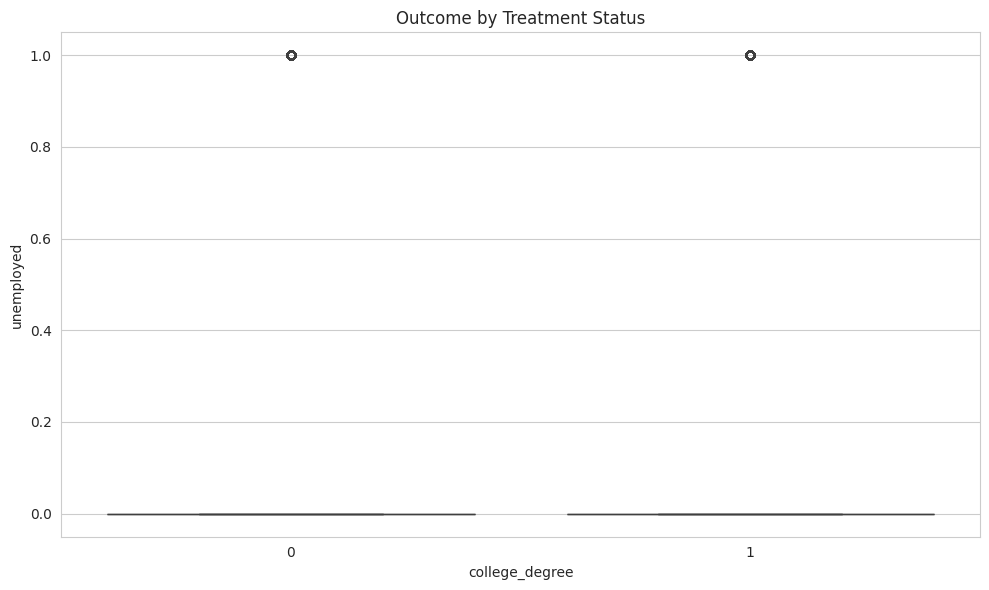

In [55]:
# --- EDA: Treatment-Outcome Visualization ---
fig, ax = plt.subplots()
sns.boxplot(data=df, x=treatment_col, y='unemployed', ax=ax)
ax.set_title('Outcome by Treatment Status')
plt.tight_layout()
plt.show()

Not useful visualization since we're testing binary variables

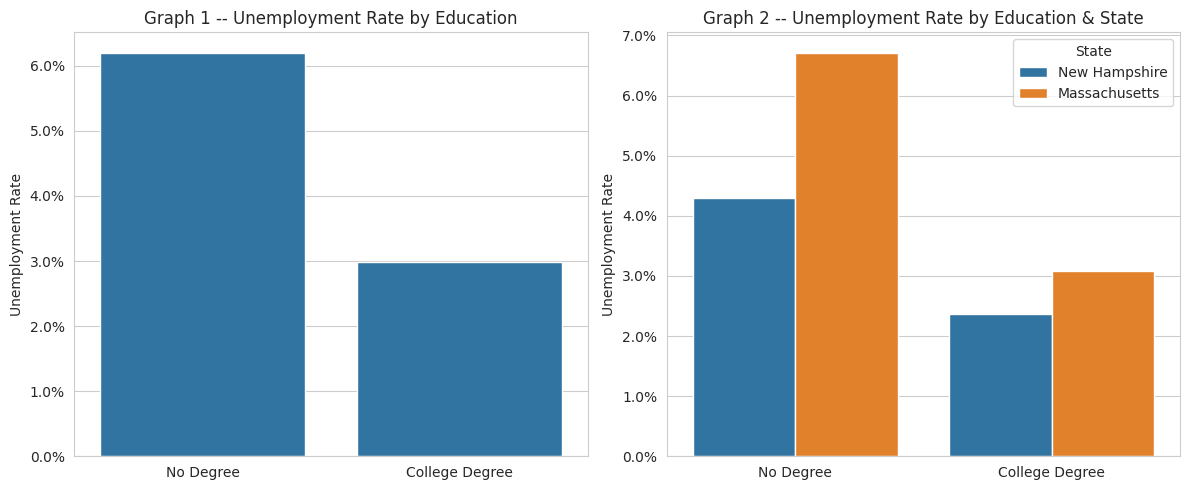

In [56]:
#better plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#unemp rate vs college degree
unemp_rate = df.groupby('college_degree')['unemployed'].mean().reset_index()
unemp_rate['college_degree'] = unemp_rate['college_degree'].map({0: 'No Degree', 1: 'College Degree'})
sns.barplot(data=unemp_rate, x='college_degree', y='unemployed', ax=axes[0])
axes[0].set_title('Graph 1 -- Unemployment Rate by Education')
axes[0].set_ylabel('Unemployment Rate')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

#unemp rate vs college degree by state
unemp_state = df.groupby(['is_MA', 'college_degree'])['unemployed'].mean().reset_index()
unemp_state['State'] = unemp_state['is_MA'].map({0: 'New Hampshire', 1: 'Massachusetts'})
unemp_state['college_degree'] = unemp_state['college_degree'].map({0: 'No Degree', 1: 'College Degree'})
sns.barplot(data=unemp_state, x='college_degree', y='unemployed', hue='State', ax=axes[1])
axes[1].set_title('Graph 2 -- Unemployment Rate by Education & State')
axes[1].set_ylabel('Unemployment Rate')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.show()

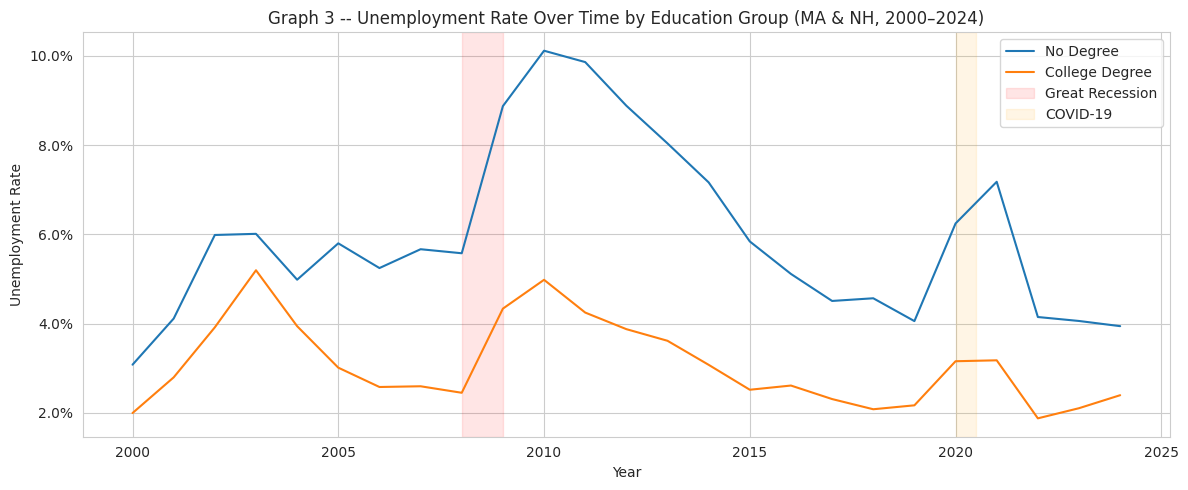

In [57]:
#unemp rate over time per educ group
unemp_time = df.groupby(['YEAR', 'college_degree'])['unemployed'].mean().reset_index()
unemp_time['college_degree'] = unemp_time['college_degree'].map({0: 'No Degree', 1: 'College Degree'})

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=unemp_time, x='YEAR', y='unemployed', hue='college_degree', ax=ax)
ax.set_title('Graph 3 -- Unemployment Rate Over Time by Education Group (MA & NH, 2000–2024)')
ax.set_ylabel('Unemployment Rate')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.axvspan(2008, 2009, alpha=0.1, color='red', label='Great Recession')
ax.axvspan(2020, 2020.5, alpha=0.1, color='orange', label='COVID-19')
ax.legend()
plt.tight_layout()
plt.show()

## Graph 1
Graph 1 is giving us a baseline understanding of the difference in unemployment between our group with a college degree, and our group without a college degree.We can see that our college-educated group's unemployment rate is a little over 3% less than our non-college group.

## Graph 2
Graph 2 is breaking down the simple difference in unemployment by state, which is going to be crucial to our instrumental variable analysis. This simple visualization shows us that Massachusetts has a more significant gap in unemployment rate between our college and non-college groups, while New Hampshire's unemployment rates are comparatively closer to each other.

## Graph 3
Graph 3 shows us what unemployment rates for our sample states have looked like over time for our treated and untreated groups. The college-educated group has always been lower than non-college, and has had less drastic spikes than what the non-college group has had, especially in the aftermath of the Great Recession and then the pandemic. This would seem to indicate that education provides some kind of stabilizing backstop when faced with extreme economic volatility.

---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

This simple comparison is expected to be biased. Document *why*.

In [58]:
# --- Naive OLS ---
X_naive = df[['college_degree']]
X_naive = sm.add_constant(X_naive)
y = df['unemployed']
naive_model = sm.OLS(y, X_naive).fit()
print(naive_model.summary())
naive_estimate = naive_model.params['college_degree']
naive_ci = naive_model.conf_int().loc['college_degree'].values
print(f'\nNaive estimate: {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])')

                            OLS Regression Results                            
Dep. Variable:             unemployed   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     4524.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:45:00   Log-Likelihood:             1.1157e+05
No. Observations:              759980   AIC:                        -2.231e+05
Df Residuals:                  759978   BIC:                        -2.231e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0620      0.000    183.

**Why the naive estimate is biased:** Naive estimate is biased because it is an example of the omitted variable bias. There are variables that coexist with whether someone has a college degree that also help to explain their employment status; this effect is not being captured by the naive model. There are observed effects that a college-degree has on unemployment rate, but the unobserved effects are being included as well which is likely causing downward bias overstating negative effects on the estimate shown above.

### 3b. Causal Estimate

In [66]:
# --- Causal Method: Instrumental Variables ---
df = pd.read_csv('educ_cleaned_instr.csv')

df = df[[c for c in df.columns if not c.startswith('yr_')]]
year_dummies = pd.get_dummies(df['YEAR'], prefix='yr', drop_first=True).astype(int)
df = pd.concat([df, year_dummies], axis=1)
year_cols = year_dummies.columns.tolist()

# Define variables
treatment  = 'college_degree'
instrument = 'tuition_per_fte'
controls   = ['AGE', 'SEX', 'RACE', 'HISPAN', 'is_MA'] + year_cols

# First stage
X_fs    = sm.add_constant(df[[instrument] + controls])
fs      = sm.OLS(df[treatment], X_fs).fit(cov_type='HC1')

fs_coef  = fs.params[instrument]
fs_se    = fs.bse[instrument]
fs_tstat = fs.tvalues[instrument]
fs_pval  = fs.pvalues[instrument]
fs_fstat = fs.fvalue

print("=" * 55)
print("FIRST STAGE: tuition_per_fte → college_degree")
print("=" * 55)
print(f"Coefficient : {fs_coef:.6f}")
print(f"Std Error   : {fs_se:.6f}")
print(f"T-Statistic : {fs_tstat:.3f}")
print(f"P-Value     : {fs_pval:.4f}")
print(f"F-Statistic : {fs_fstat:.2f}\n")

if fs_fstat > 104:
    print(f"  F = {fs_fstat:.2f} > 104 — strong instrument (Lee et al. 2022) ✓")
elif fs_fstat > 10:
    print(f"  F = {fs_fstat:.2f} > 10  — relevant instrument (Stock-Yogo) ✓")
else:
    print(f"  F = {fs_fstat:.2f} < 10  — WEAK INSTRUMENT WARNING ✗")
print()
print("Interpretation:")
print(f"  A $1 increase in tuition per FTE changes college degree")
print(f"  attainment probability by {fs_coef:.6f} percentage points.")

FIRST STAGE: tuition_per_fte → college_degree
Coefficient : -0.000005
Std Error   : 0.000001
T-Statistic : -3.772
P-Value     : 0.0002
F-Statistic : 1176.33

  F = 1176.33 > 104 — strong instrument (Lee et al. 2022) ✓

Interpretation:
  A $1 increase in tuition per FTE changes college degree
  attainment probability by -0.000005 percentage points.


In [67]:
#Second stage

### 3c. Prediction Model (for comparison)

In [ ]:
# --- Predictive Model (NOT causal — for comparison only) ---
from sklearn.metrics import r2_score, mean_squared_error

all_features = ['college_degree', 'SEX', 'AGE', 'INCTOT']
rf = RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE)
y_pred = cross_val_predict(rf, df[all_features], df['unemployed'], cv=5)

print(f'Prediction R²: {r2_score(df["unemployed"], y_pred):.3f}')
print(f'Prediction RMSE: {np.sqrt(mean_squared_error(df["unemployed"], y_pred)):.3f}')
print('\nNote: This tells us how well we can PREDICT the outcome,')
print('but NOT how the treatment CAUSES changes in the outcome.')

### 3d. Compare Naive vs. Causal

> The naive estimate is [X], the causal estimate is [Y]. The difference of [Z] is attributable to [confounding/selection bias].

In [ ]:
# --- Comparison Plot ---
# fig, ax = plt.subplots(figsize=(8, 5))
#
# estimates = ['Naive OLS', 'Causal (DML)']
# points = [naive_estimate, causal_estimate]
# ci_lower = [naive_ci[0], causal_ci[0]]
# ci_upper = [naive_ci[1], causal_ci[1]]
# errors = [[p - l for p, l in zip(points, ci_lower)],
#           [u - p for p, u in zip(points, ci_upper)]]
#
# ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=8,
#             markersize=10, linewidth=2, color='#1a237e')
# ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# ax.set_ylabel('Estimated Effect')
# ax.set_title('Naive vs. Causal Estimate')
# plt.tight_layout()
# plt.show()

### 3e. Robustness Check

In [ ]:
# --- Robustness: Different nuisance model ---
# dml_robust = LinearDML(
#     model_y=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     model_t=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     cv=5,
#     random_state=RANDOM_STATE
# )
# dml_robust.fit(Y, T, X=X, W=W)
# robust_ate = dml_robust.ate(X)
# robust_ci = dml_robust.ate_interval(X, alpha=0.05)
# print(f'Robustness ATE (RF nuisance): {robust_ate:.4f}')
# print(f'95% CI: [{robust_ci[0]:.4f}, {robust_ci[1]:.4f}]')

---
## Part 4: Threats to Identification

**Minimum 500 words. Be honest — this is where you demonstrate critical thinking.**

### 1. Most Serious Threat

- **Threat:** ___
- **Direction of bias:** [Does this make my estimate too large or too small?]
- **What would address it:** [Ideal data, instrument, or design]

### 2. Second Threat

- **Threat:** ___
- **Why it matters:** ___
- **Partial mitigation:** [What I did or could do]

### 3. What I Cannot Rule Out

[Be honest about what remains. This limitation means my estimate should be interpreted as ___ rather than a definitive causal effect.]

---
## Part 5: Streamlit Dashboard Export

Copy the template below into a file called `app.py` in your project repo. Customize the what-if logic with your actual model.

**Deploy to Streamlit Community Cloud** and submit the permanent URL.

In [ ]:
# Save this as app.py in your project repo

streamlit_template = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="Consulting Report Dashboard", layout="wide")
st.title("Consulting Report: [Your Title]")

# --- Sidebar: What-If Controls ---
st.sidebar.header("What-If Scenarios")

treatment_multiplier = st.sidebar.slider(
    "Treatment intensity multiplier",
    min_value=0.5, max_value=3.0, value=1.0, step=0.1
)

# TODO: Add more sliders for your specific parameters
# control_level = st.sidebar.selectbox("Control scenario", ["Low", "Medium", "High"])

# --- Load your fitted model or pre-computed results ---
# Option 1: Load a pickled model
# import joblib
# model = joblib.load("fitted_model.pkl")

# Option 2: Use pre-computed coefficients
baseline_ate = 0.0    # TODO: Replace with your causal estimate
baseline_se = 0.0     # TODO: Replace with your standard error

# --- Compute What-If Estimate ---
adjusted_ate = baseline_ate * treatment_multiplier
adjusted_se = baseline_se * treatment_multiplier
ci_lower = adjusted_ate - 1.96 * adjusted_se
ci_upper = adjusted_ate + 1.96 * adjusted_se

# --- Display Results ---
col1, col2, col3 = st.columns(3)
col1.metric("Estimated Effect", f"{adjusted_ate:.3f}")
col2.metric("95% CI Lower", f"{ci_lower:.3f}")
col3.metric("95% CI Upper", f"{ci_upper:.3f}")

st.markdown(f"""
> **What-if interpretation:** If treatment intensity is multiplied by
> {treatment_multiplier:.1f}x, the estimated effect changes to
> {adjusted_ate:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]).
""")

# --- Uncertainty Visualization ---
multipliers = np.arange(0.5, 3.1, 0.1)
ates = baseline_ate * multipliers
ses = baseline_se * multipliers

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=multipliers, y=ates + 1.96 * ses,
    mode="lines", line=dict(width=0), showlegend=False
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates - 1.96 * ses,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(26,35,126,0.2)", name="95% CI"
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates,
    mode="lines", line=dict(color="#1a237e", width=2), name="Estimated Effect"
))
fig.add_vline(x=treatment_multiplier, line_dash="dash", line_color="red",
              annotation_text=f"Current: {treatment_multiplier:.1f}x")
fig.update_layout(
    title="What-If: Effect vs. Treatment Intensity",
    xaxis_title="Treatment Intensity Multiplier",
    yaxis_title="Estimated Causal Effect",
    template="plotly_white"
)
st.plotly_chart(fig, use_container_width=True)

# --- Counterfactual Scenario ---
st.subheader("Counterfactual: What if treatment intensity doubled?")
counterfactual_ate = baseline_ate * 2.0
counterfactual_ci = (counterfactual_ate - 1.96 * baseline_se * 2.0,
                     counterfactual_ate + 1.96 * baseline_se * 2.0)
st.write(f"If treatment intensity doubled, the estimated effect would be "
         f"**{counterfactual_ate:.3f}** (95% CI: [{counterfactual_ci[0]:.3f}, {counterfactual_ci[1]:.3f}]).")
'''

# Uncomment to write the template to disk:
# with open('app.py', 'w') as f:
#     f.write(streamlit_template)
# print('app.py written. Deploy to Streamlit Community Cloud.')

print('Streamlit template ready. Uncomment the write block above to export.')

---
## Part 6: Presentation Script

**5 minutes total. Practice with a timer.**

| Segment | Time | Your Script |
|---------|------|-------------|
| **Hook** | 30s | ___ |
| **Problem** | 60s | ___ |
| **Method** | 60s | ___ |
| **Finding** | 60s | ___ |
| **Recommendation** | 60s | ___ |
| **Defense** | 30s | ___ |

### Adversarial Prep

| Question Category | Your Prepared Answer |
|-------------------|---------------------|
| "How do you know this is causal?" | ___ |
| "Why this model?" | ___ |
| "Would this generalize?" | ___ |
| "Is the effect large enough?" | ___ |

---
## Part 7: AI Methodology Appendix (P.R.I.M.E.)

Document at least 3 significant AI interactions.

### Entry 1: [Task — e.g., Code Generation]

- **Prompt:** [What you asked the AI]
- **Response:** [Summary of what the AI produced]
- **Iterate:** [What you changed or asked to refine]
- **Modify:** [How you adapted the output for your specific use case]
- **Evaluate:** [How you verified correctness — tests run, sources checked, logic reviewed]

### Entry 2: [Task — e.g., Analysis Assistance]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___

### Entry 3: [Task — e.g., Writing / Literature Review]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___